In [1]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")

print(df.shape)
print(df.columns.tolist())
print(df[["sales_amount", "discount_pct"]].head())
print(df[["sales_amount", "discount_pct"]].isna().sum())

(4310, 21)
['order_id', 'order_date', 'customer_id', 'customer_name', 'age', 'gender', 'region', 'city', 'product_category', 'product_name', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit', 'shipping_cost', 'payment_method', 'customer_satisfaction', 'return_flag', 'order_status', 'days_to_ship']
   sales_amount  discount_pct
0       4043.14           NaN
1       9147.31          0.08
2     110156.97          0.14
3     262066.11          0.17
4        323.95          0.31
sales_amount     30
discount_pct    167
dtype: int64


In [2]:
# Keep rows that have both sales amount and discount information
analysis_df = df[["sales_amount", "discount_pct"]].dropna().copy()

# Treat a discount greater than 0 as "discounted"
analysis_df["discount_group"] = analysis_df["discount_pct"].apply(
    lambda value: "Discounted" if value > 0 else "No discount"
)

print(analysis_df["discount_group"].value_counts())
print(analysis_df.groupby("discount_group")["sales_amount"].agg(["count", "mean", "median", "std"]))

discount_group
Discounted     4098
No discount      45
Name: count, dtype: int64
                count           mean     median           std
discount_group                                               
Discounted       4098   57082.931410   9296.395  1.749878e+05
No discount        45  500397.124444  20334.290  2.576083e+06


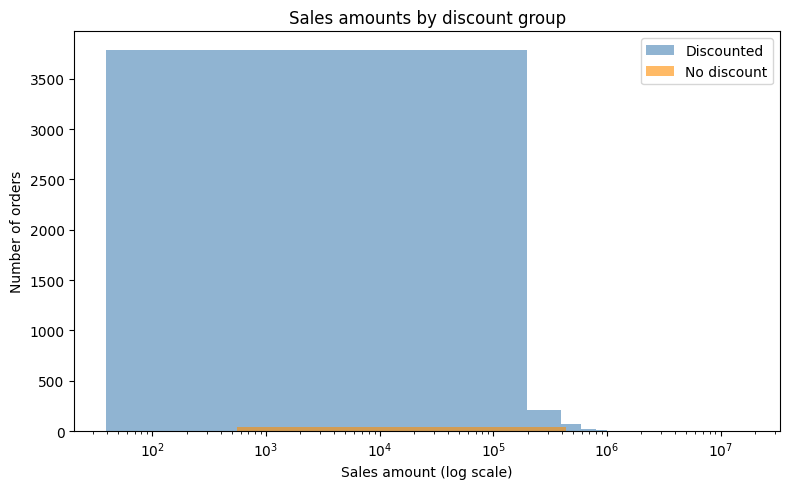

In [3]:
import matplotlib.pyplot as plt

# A few very large values can hide most orders, so use a log scale for readability
plt.figure(figsize=(8, 5))

for group, color in [("Discounted", "steelblue"), ("No discount", "darkorange")]:
    values = analysis_df.loc[
        analysis_df["discount_group"] == group, "sales_amount"
    ]
    plt.hist(values, bins=40, alpha=0.6, label=group, color=color)

plt.xscale("log")
plt.xlabel("Sales amount (log scale)")
plt.ylabel("Number of orders")
plt.title("Sales amounts by discount group")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
from scipy import stats
import numpy as np

discounted = analysis_df.loc[
    analysis_df["discount_group"] == "Discounted", "sales_amount"
]
no_discount = analysis_df.loc[
    analysis_df["discount_group"] == "No discount", "sales_amount"
]

# Welch's two-sample t-test
result = stats.ttest_ind(discounted, no_discount, equal_var=False)

# Difference in means: discounted minus no discount
mean_difference = discounted.mean() - no_discount.mean()

# Welch confidence interval for the difference in means
n1, n2 = len(discounted), len(no_discount)
v1, v2 = discounted.var(ddof=1), no_discount.var(ddof=1)
se = np.sqrt(v1 / n1 + v2 / n2)

df_welch = (v1 / n1 + v2 / n2) ** 2 / (
    (v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1)
)

t_critical = stats.t.ppf(0.975, df_welch)
ci_low = mean_difference - t_critical * se
ci_high = mean_difference + t_critical * se

print(f"Mean difference (discounted - no discount): {mean_difference:,.2f}")
print(f"Welch t-statistic: {result.statistic:.3f}")
print(f"Degrees of freedom: {df_welch:.2f}")
print(f"p-value: {result.pvalue:.6g}")
print(f"95% confidence interval: [{ci_low:,.2f}, {ci_high:,.2f}]")

Mean difference (discounted - no discount): -443,314.19
Welch t-statistic: -1.154
Degrees of freedom: 44.00
p-value: 0.254577
95% confidence interval: [-1,217,272.46, 330,644.07]


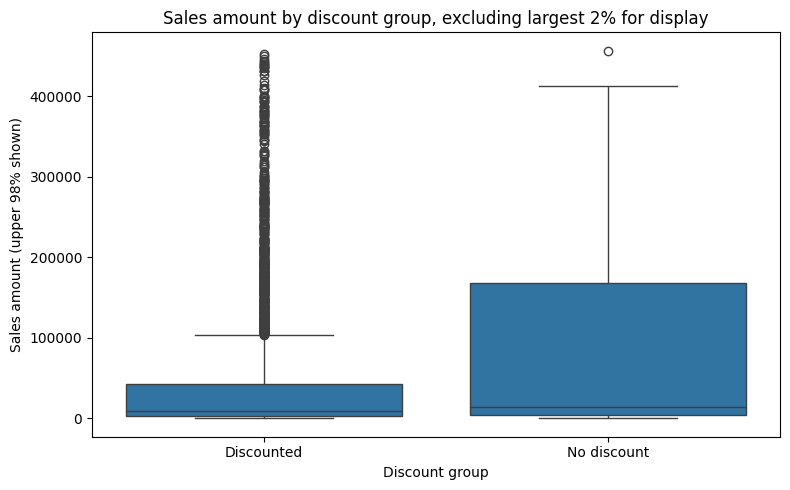

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Keep the middle 98% of sales values just for this display
upper_limit = analysis_df["sales_amount"].quantile(0.98)
plot_df = analysis_df[analysis_df["sales_amount"] <= upper_limit]

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x="discount_group", y="sales_amount")
plt.xlabel("Discount group")
plt.ylabel("Sales amount (upper 98% shown)")
plt.title("Sales amount by discount group, excluding largest 2% for display")
plt.tight_layout()
plt.show()